In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns

In [2]:
print(yf.__version__) 

1.3.0


In [3]:
# Скачиваем данные за последний год (1y)
# Интервал '1d' означает один бар = один день
df = yf.download('EURUSD=X', period='1y', interval='1d')

[*********************100%***********************]  1 of 1 completed


In [4]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,EURUSD=X,EURUSD=X,EURUSD=X,EURUSD=X,EURUSD=X
Date,,,,,
2026-04-22,1.174426,1.176111,1.171372,1.174577,0
2026-04-23,1.170604,1.171646,1.167924,1.170494,0
2026-04-24,1.168388,1.172058,1.167324,1.168402,0
2026-04-27,1.170645,1.175641,1.170590,1.170590,0
2026-04-28,1.168770,1.173020,1.168634,1.172608,0


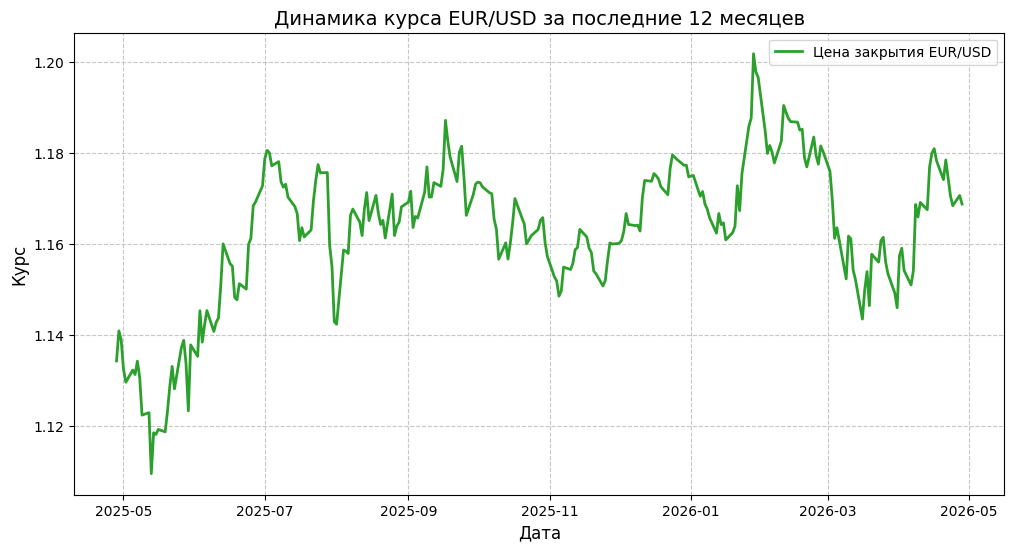

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label='Цена закрытия EUR/USD', color='#2ca02c', linewidth=2)

# Добавляем детали
plt.title('Динамика курса EUR/USD за последние 12 месяцев', fontsize=14)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Курс', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.show()

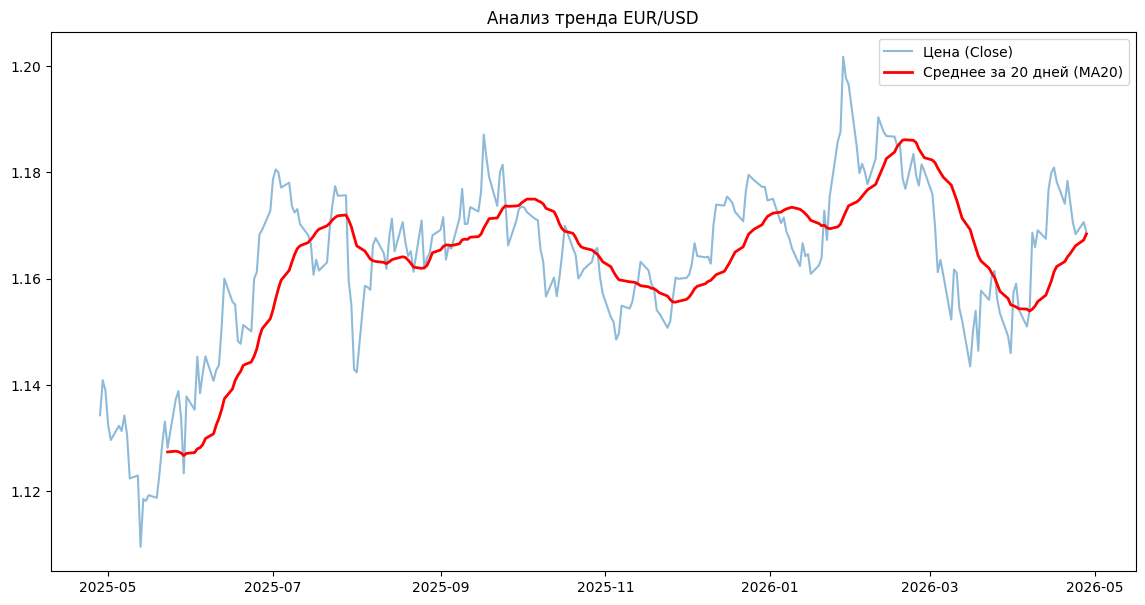

In [6]:
# Создаем новую колонку MA20 (аналог WINDOW FUNCTION в SQL)
df['MA20'] = df['Close'].rolling(window=20).mean()

# Строим график снова, но уже с двумя линиями
plt.figure(figsize=(14, 7))
plt.plot(df['Close'], label='Цена (Close)', alpha=0.5)
plt.plot(df['MA20'], label='Среднее за 20 дней (MA20)', color='red', linewidth=2)

plt.title('Анализ тренда EUR/USD')
plt.legend()
plt.show()

In [7]:
# Находим экстремумы и превращаем их в обычные числа (float)
price_min = float(df['Close'].min())
price_max = float(df['Close'].max())
price_mean = float(df['Close'].mean())

print(f"Минимальная цена за год: {price_min:.4f}")
print(f"Максимальная цена за год: {price_max:.4f}")
print(f"Средняя цена за год: {price_mean:.4f}")

Минимальная цена за год: 1.1096
Максимальная цена за год: 1.2018
Средняя цена за год: 1.1628


C:\Users\fande\AppData\Local\Temp\ipykernel_15988\775194020.py:2: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  price_min = float(df['Close'].min())
C:\Users\fande\AppData\Local\Temp\ipykernel_15988\775194020.py:3: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  price_max = float(df['Close'].max())
C:\Users\fande\AppData\Local\Temp\ipykernel_15988\775194020.py:4: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  price_mean = float(df['Close'].mean())


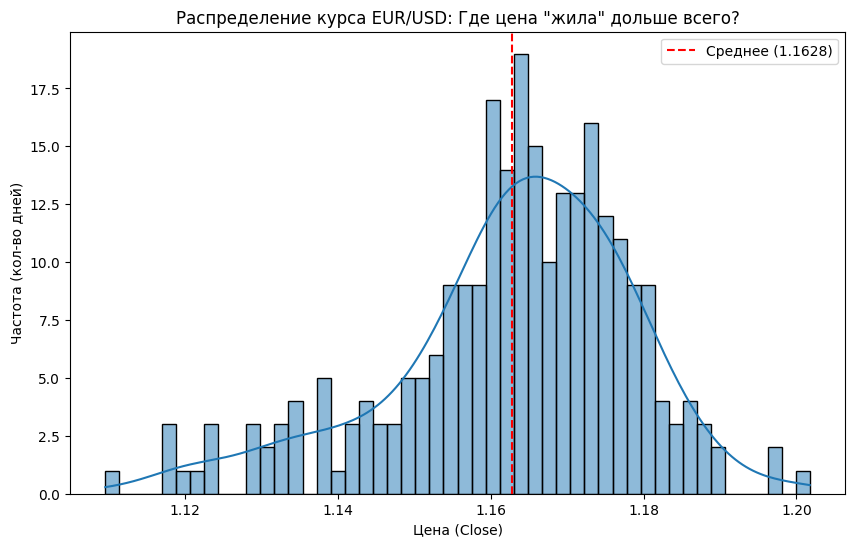

In [8]:
plt.figure(figsize=(10, 6))

# Рисуем гистограмму распределения цен
sns.histplot(df['Close'], bins=50, kde=True, color='royalblue')

# Добавляем вертикальную линию среднего значения
plt.axvline(price_mean, color='red', linestyle='--', label=f'Среднее ({price_mean:.4f})')

plt.title('Распределение курса EUR/USD: Где цена "жила" дольше всего?')
plt.xlabel('Цена (Close)')
plt.ylabel('Частота (кол-во дней)')
plt.legend()
plt.show()

In [9]:
# Сохраняем результат в файл
df.to_csv('eur_usd_cleaned.csv')